In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
file_path = r'C:\Users\sharif\Desktop\Final5.xlsx'
df = pd.read_excel(file_path)
df.head()

,"STREAMS(""METHANOL"").F","STREAMS(""METHANOL"").T","STREAMS(""METHANOL"").P","STREAMS(""FV"").F","STREAMS(""FV"").T","STREAMS(""FV"").P","STREAMS(""FV"").Zmn(""1-BUT-01"")","STREAMS(""FV"").Zmn(""ISOBU-01"")","STREAMS(""P1"").F","STREAMS(""P1"").T",...,"BLOCKS(""RDCOLUMN"").Stage(4).T","BLOCKS(""RDCOLUMN"").Stage(5).T","BLOCKS(""RDCOLUMN"").Stage(6).T","BLOCKS(""RDCOLUMN"").Stage(7).T","BLOCKS(""RDCOLUMN"").Stage(8).T","BLOCKS(""RDCOLUMN"").Stage(9).T","BLOCKS(""RDCOLUMN"").Stage(10).T","BLOCKS(""RDCOLUMN"").Stage(11).T","STREAMS(""P1"").Zmn(""1-BUT-01"")","STREAMS(""P2"").Zmn(""METHY-01"")"
0,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
1,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
2,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
3,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
4,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3313,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974


In [3]:
df.describe

<bound method NDFrame.describe of        STREAMS("METHANOL").F  STREAMS("METHANOL").T  STREAMS("METHANOL").P  \
0                    712.082                  46.85                1.01325   
1                    712.082                  46.85                1.01325   
2                    712.082                  46.85                1.01325   
3                    712.082                  46.85                1.01325   
4                    712.082                  46.85                1.01325   
...                      ...                    ...                    ...   
12648                718.993                  46.85                1.01325   
12649                718.993                  46.85                1.01325   
12650                718.993                  46.85                1.01325   
12651                718.993                  46.85                1.01325   
12652                718.993                  46.85                1.01325   

       STREAMS("FV").F  STREA

# PreProcessing

In [4]:
x = df.drop(['STREAMS("P2").Zmn("METHY-01")','STREAMS("P1").Zmn("1-BUT-01")'] , axis=1).values
y = df[['STREAMS("P2").Zmn("METHY-01")','STREAMS("P1").Zmn("1-BUT-01")']].values

In [5]:
x

array([[712.082  ,  46.85   ,   1.01325, ..., 123.67   , 123.896  ,
        128.634  ],
       [712.082  ,  46.85   ,   1.01325, ..., 123.67   , 123.896  ,
        128.634  ],
       [712.082  ,  46.85   ,   1.01325, ..., 123.67   , 123.896  ,
        128.634  ],
       ...,
       [718.993  ,  46.85   ,   1.01325, ..., 106.044  , 104.518  ,
        107.674  ],
       [718.993  ,  46.85   ,   1.01325, ..., 106.044  , 104.518  ,
        107.674  ],
       [718.993  ,  46.85   ,   1.01325, ..., 106.044  , 104.518  ,
        107.674  ]], shape=(12653, 36))

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [7]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_train = scaler_x.fit_transform(x_train)
x_test = scaler_x.transform(x_test)

y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)

In [8]:
x_train = np.expand_dims(x_train, axis=1)
x_test = np.expand_dims(x_test, axis=1)

In [9]:
def build_tft_model(input_shape, output_dim, d_model=64, dff=128, num_heads=8, dropout_rate=0.1):

    inputs = layers.Input(shape=input_shape)

    x = layers.Dense(d_model)(inputs)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout_rate)(attn_output)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

    ffn = tf.keras.Sequential([
        layers.Dense(dff, activation='relu'),
        layers.Dense(d_model)
    ])
    ffn_output = ffn(x)
    ffn_output = layers.Dropout(dropout_rate)(ffn_output)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(output_dim)(x)

    model = tf.keras.Model(inputs, outputs)
    return model

input_shape = x_train.shape[1:]
output_dim = y_train.shape[1]

tft_model = build_tft_model(input_shape, output_dim, d_model=128, dff=256, num_heads=8, dropout_rate=0.2)

tft_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='mse',
    metrics=['mae']
)

tft_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1, 36)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 128)    │      4,736 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1, 128)    │        256 │ dense[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 128)    │    527,488 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 1, 128)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 128)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 128)    │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 1, 128)    │     65,920 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1, 128)    │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 128)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 128)    │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 2)         │        258 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 599,170 (2.29 MB)

 Trainable params: 599,170 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = tft_model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=200,
    batch_size=32,
    verbose=1
)

Epoch 1/200
317/317 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - loss: 0.6153 - mae: 0.4912 - val_loss: 0.0872 - val_mae: 0.1387
Epoch 2/200
317/317 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - loss: 0.1497 - mae: 0.2635 - val_loss: 0.0430 - val_mae: 0.1082
Epoch 3/200
317/317 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - loss: 0.0918 - mae: 0.2092 - val_loss: 0.0215 - val_mae: 0.0884
Epoch 4/200
317/317 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - loss: 0.0599 - mae: 0.1718 - val_loss: 0.0159 - val_mae: 0.0717
Epoch 5/200
317/317 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - loss: 0.0464 - mae: 0.1500 - val_loss: 0.0164 - val_mae: 0.0737
Epoch 6/200
317/317 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - loss: 0.0373 - mae: 0.1332 - val_loss: 0.0102 - val_mae: 0.0500
Epoch 7/200
317/317 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - loss: 0.0315 - mae: 0.1200 - val_loss: 0.0092 - val_mae: 0.0506
Epoch 8/200
317/317 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - loss: 0.0321 - mae: 0.1166 - val_loss: 0.0085 - val_mae: 0.0474
Epoch 9/200
317/317 ━━━━━━━━━━━━

In [11]:
test_loss, test_mae = tft_model.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test MAE: {test_mae}")

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018 - mae: 0.0198
Test Loss: 0.0022904390934854746
Test MAE: 0.019722413271665573


In [12]:
y_pred = tft_model.predict(x_test)

80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [13]:
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score

mse = mean_squared_error(y_test , y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:{mse}")
print(f"MAE:{mae}")
print(f"R2 Score:{r2}")

MSE:0.002290439000325265
MAE:0.019722416232288056
R2 Score:0.9976783593181501


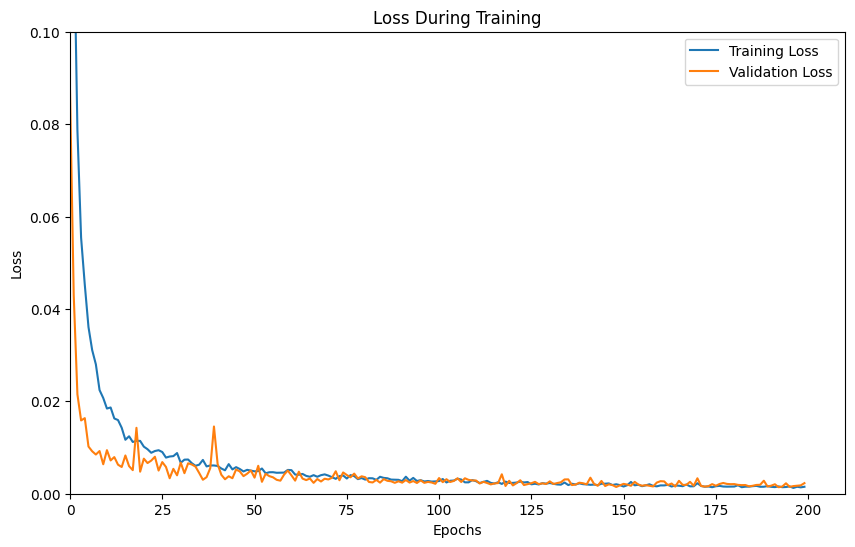

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss During Training')
plt.legend()
plt.xlim(0,210)
plt.ylim(0,0.1)
plt.show()

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

test_loss, test_mae = tft_model.evaluate(x_test, y_test, verbose=1)

print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test Mean Absolute Error (MAE): {test_mae:.4f}")

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018 - mae: 0.0198
Test Loss (MSE): 0.0023
Test Mean Absolute Error (MAE): 0.0197


In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = tft_model.predict(x_test)

y_test_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred)

mse = mean_squared_error(y_test_inv, y_pred_inv)
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Mean Squared Error (MSE): 0.0000
Mean Absolute Error (MAE): 0.0005
R^2 Score: 0.9977


In [17]:
# انتخاب 20 نمونه
results = pd.DataFrame({
    'Actual MoleFractionTX': y_test_inv[:, 0],
    'Predicted MoleFractionTX': y_pred_inv[:, 0],
    'Actual MoleFractionHX': y_test_inv[:, 1],
    'Predicted MoleFractionHX': y_pred_inv[:, 1]
})
results.head()

,Actual MoleFractionTX,Predicted MoleFractionTX,Actual MoleFractionHX,Predicted MoleFractionHX
0,0.965668,0.965646,0.937514,0.937274
1,0.727290,0.720947,0.941283,0.943581
2,0.965202,0.966009,0.934364,0.934040
3,0.965974,0.967022,0.936495,0.936344
4,0.960999,0.960978,0.940697,0.940856


Total number of samples: 2531
Plotting first 5000 samples.


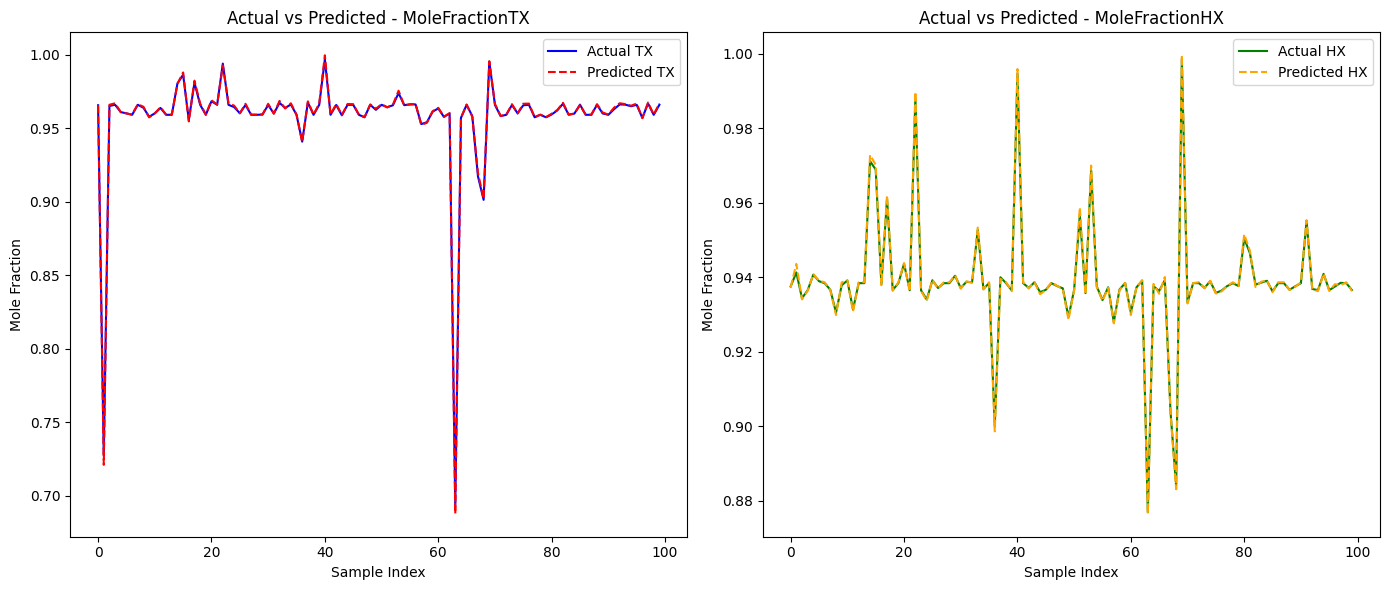

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# بررسی تعداد کل داده‌ها
num_samples = len(results)
print(f"Total number of samples: {num_samples}")

# اگر داده‌ها بیشتر از 5000 بودند، فقط 5000 تای اول را انتخاب کن
if num_samples >= 100:
    subset = results.iloc[:100]
    print("Plotting first 5000 samples.")
else:
    subset = results
    print("Plotting all available samples.")

# رسم نمودار
plt.figure(figsize=(14, 6))

# MoleFractionTX
plt.subplot(1, 2, 1)
plt.plot(subset['Actual MoleFractionTX'].values, label='Actual TX', color='blue')
plt.plot(subset['Predicted MoleFractionTX'].values, label='Predicted TX', color='red', linestyle='--')
plt.title('Actual vs Predicted - MoleFractionTX')
plt.xlabel('Sample Index')
plt.ylabel('Mole Fraction')
plt.legend()

# MoleFractionHX
plt.subplot(1, 2, 2)
plt.plot(subset['Actual MoleFractionHX'].values, label='Actual HX', color='green')
plt.plot(subset['Predicted MoleFractionHX'].values, label='Predicted HX', color='orange', linestyle='--')
plt.title('Actual vs Predicted - MoleFractionHX')
plt.xlabel('Sample Index')
plt.ylabel('Mole Fraction')
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
def percentage_within_tolerance(y_true, y_pred, tolerance):
    diff = np.abs(y_true - y_pred)
    within_tol = np.sum(diff <= tolerance)
    return (within_tol / len(y_true)) * 100

In [20]:
tolerances = [0.005, 0.002, 0.001]

# دو خروجی داریم: TX (ستون 0) و HX (ستون 1)
tx_true = y_test_inv[:, 0]
tx_pred = y_pred_inv[:, 0]
hx_true = y_test_inv[:, 1]
hx_pred = y_pred_inv[:, 1]

tx_results = []
hx_results = []

In [21]:
for tol in tolerances:
    tx_acc = percentage_within_tolerance(tx_true, tx_pred, tolerance=tol)
    hx_acc = percentage_within_tolerance(hx_true, hx_pred, tolerance=tol)
    tx_results.append(tx_acc)
    hx_results.append(hx_acc)
    print(f"TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±{tol}: {tx_acc:.2f}%")
    print(f"HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±{tol}: {hx_acc:.2f}%")
    print('-'*50)

TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.005: 98.81%
HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.005: 99.88%
--------------------------------------------------
TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.002: 96.76%
HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.002: 97.43%
--------------------------------------------------
TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.001: 83.64%
HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.001: 91.23%
--------------------------------------------------


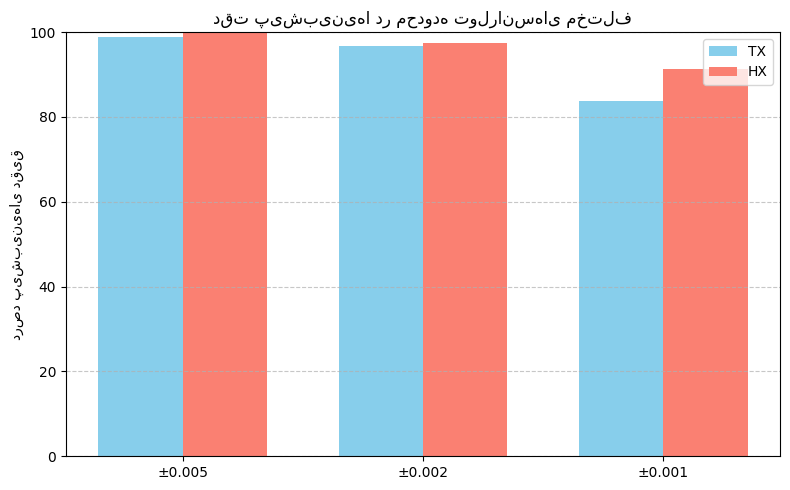

In [22]:
import matplotlib.pyplot as plt
x_labels = [f"±{tol}" for tol in tolerances]
x = np.arange(len(tolerances))

plt.figure(figsize=(8, 5))
bar_width = 0.35

plt.bar(x - bar_width/2, tx_results, width=bar_width, label='TX', color='skyblue')
plt.bar(x + bar_width/2, hx_results, width=bar_width, label='HX', color='salmon')

plt.xticks(x, x_labels)
plt.ylim(0, 100)
plt.ylabel("درصد پیش‌بینی‌های دقیق")
plt.title("دقت پیش‌بینی‌ها در محدوده تولرانس‌های مختلف")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [23]:
import shap
import pandas as pd

d:\ArshadProjectVSCode\final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
feature_names = df.drop([
    'STREAMS("P2").Zmn("METHY-01")',
    'STREAMS("P1").Zmn("1-BUT-01")'
], axis=1).columns.tolist()

In [25]:
x_sample = x_train[:100]  # شکلی مانند (100, 1, 15)
x_test_sample = x_test[:100]

In [26]:
def model_3d_wrapper(data_2d):
    data_3d = np.expand_dims(data_2d, axis=1)  # (batch, 1, features)
    return tft_model.predict(data_3d)

In [27]:
explainer = shap.Explainer(model_3d_wrapper, x_sample[:, 0, :], feature_names=feature_names)
shap_values = explainer(x_test_sample[:, 0, :])

210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


PermutationExplainer explainer:   1%|          | 1/100 [00:00<?, ?it/s]

210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


PermutationExplainer explainer:   3%|▎         | 3/100 [00:20<04:30,  2.79s/it]

199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


...

PermutationExplainer explainer:  99%|█████████▉| 99/100 [08:36<00:05,  5.03s/it]

167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


PermutationExplainer explainer: 100%|██████████| 100/100 [08:40<00:00,  4.81s/it]

189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


PermutationExplainer explainer: 101it [08:45,  5.25s/it]                         



Feature importance for output 1


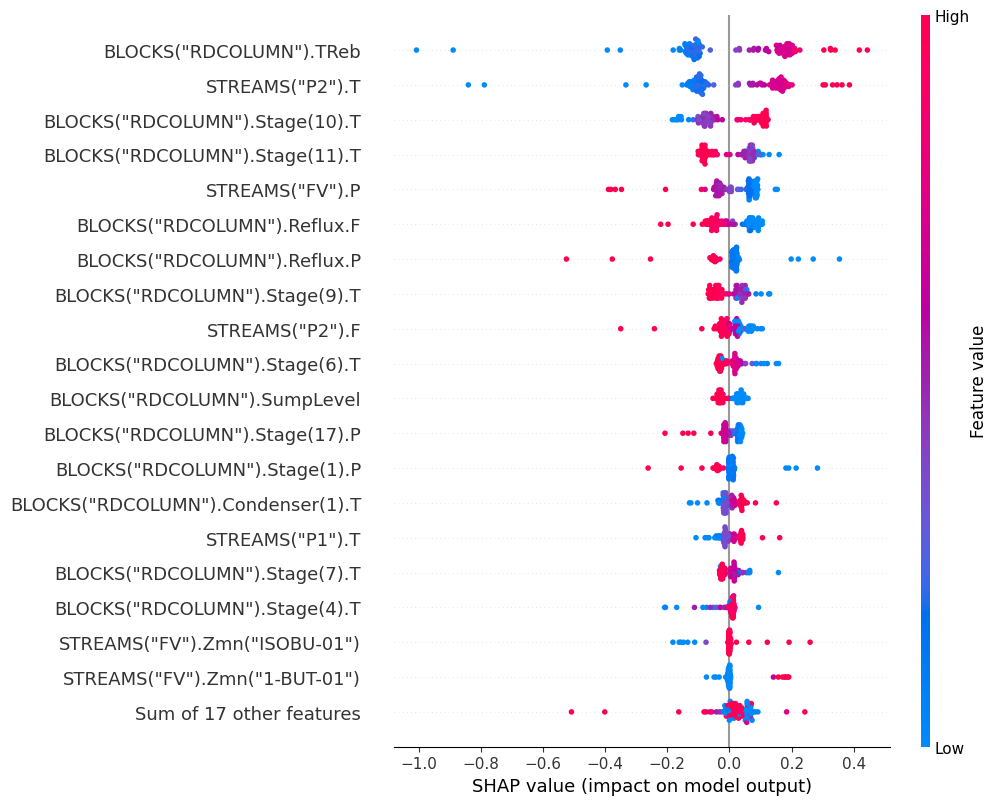


Feature importance for output 2


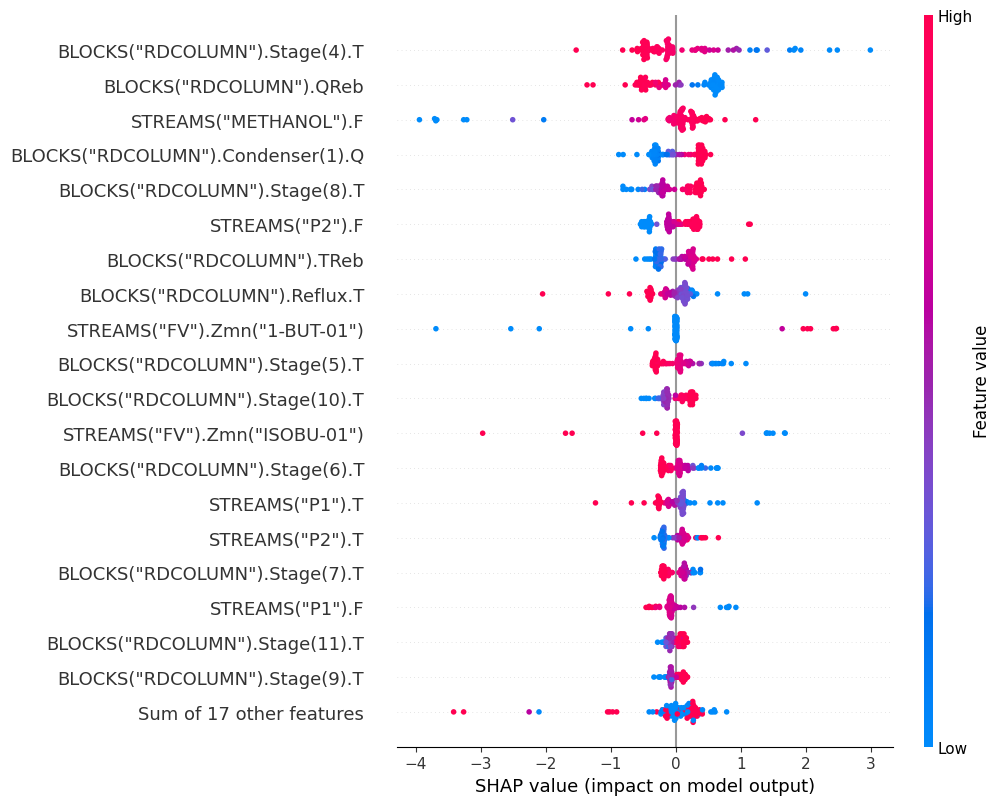

In [28]:
for i in range(y_test.shape[1]):
    print(f"\nFeature importance for output {i+1}")
    shap.plots.beeswarm(shap_values[:, :, i], max_display=20)

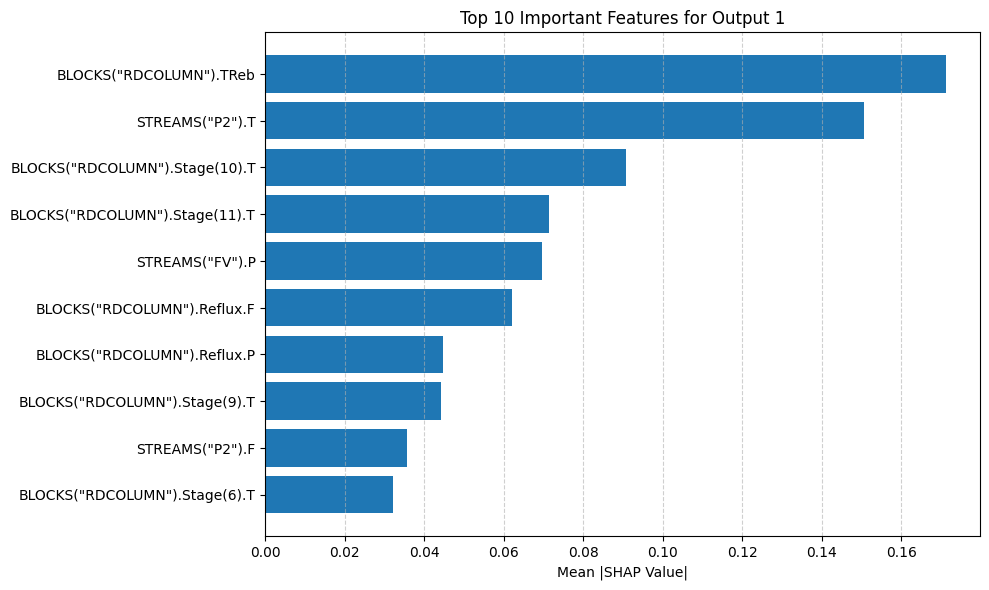

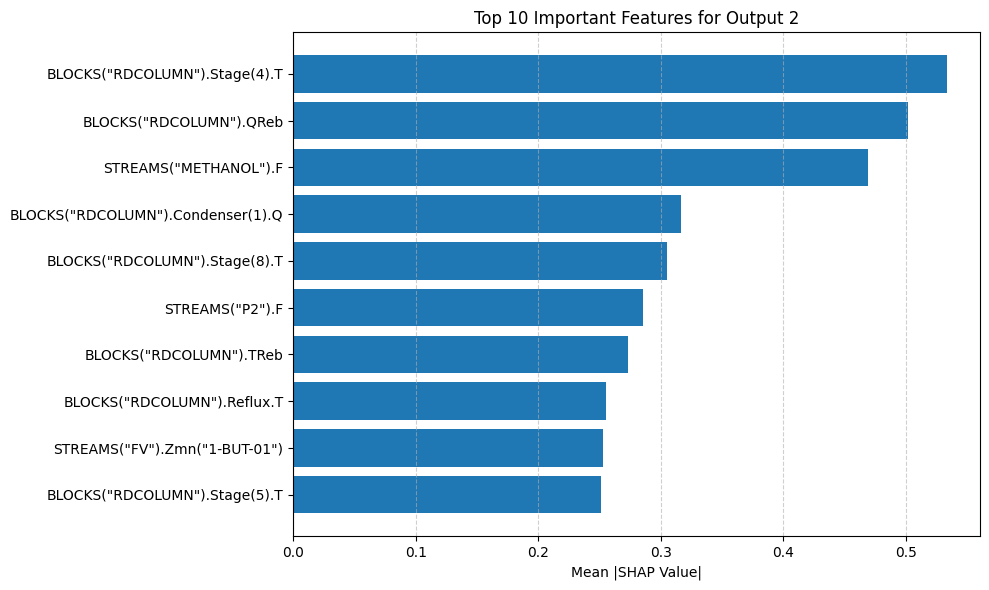

In [29]:
for output_index in range(y_test.shape[1]):
    shap_vals = shap_values[:, :, output_index].values  # shap برای خروجی i‌ام
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)  # میانگین قدر مطلق

    # گرفتن 10 فیچر مهم
    top_indices = np.argsort(mean_abs_shap)[::-1][:10]
    top_features = [feature_names[i] for i in top_indices]
    top_values = mean_abs_shap[top_indices]

    # رسم بارپلات
    plt.figure(figsize=(10, 6))
    plt.barh(top_features[::-1], top_values[::-1])  # وارونه برای نمایش درست
    plt.xlabel("Mean |SHAP Value|")
    plt.title(f"Top 10 Important Features for Output {output_index + 1}")
    plt.tight_layout()
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

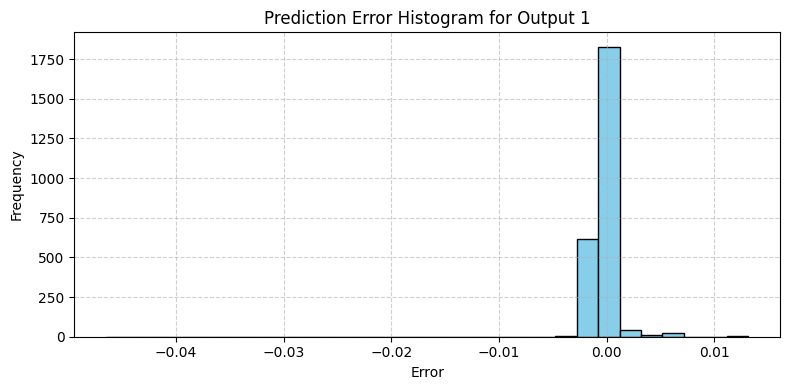

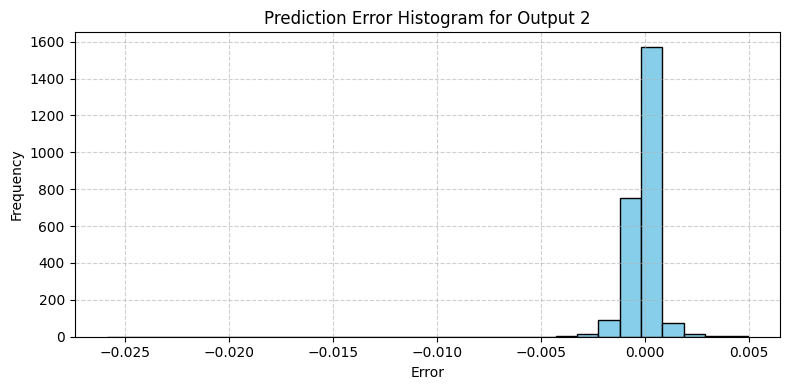

In [30]:
import matplotlib.pyplot as plt

# محاسبه خطا برای هر خروجی
errors = y_test_inv - y_pred_inv

for i in range(errors.shape[1]):
    plt.figure(figsize=(8, 4))
    plt.hist(errors[:, i], bins=30, color='skyblue', edgecolor='black')
    plt.title(f"Prediction Error Histogram for Output {i+1}")
    plt.xlabel("Error")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()